In [1]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "nagaoka_gis/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "nagaoka_gis/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 20 files belonging to 2 classes.
Found 6 files belonging to 2 classes.


In [2]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

(array([[[[ 32.857143 ,  57.857143 ,  35.857143 ],
          [ 34.614796 ,  59.614796 ,  37.614796 ],
          [ 44.561222 ,  68.561226 ,  44.561222 ],
          ...,
          [ 87.32148  , 107.32148  ,  80.32148  ],
          [ 79.79348  , 103.11491  ,  74.95419  ],
          [ 86.42352  , 109.74496  ,  81.58424  ]],
 
         [[ 39.53316  ,  64.533165 ,  42.53316  ],
          [ 44.538265 ,  69.53826  ,  47.538265 ],
          [ 50.57908  ,  74.57908  ,  50.57908  ],
          ...,
          [ 83.19903  , 103.19903  ,  76.19903  ],
          [ 75.90554  ,  97.351974 ,  69.86983  ],
          [ 87.40308  , 108.84951  ,  81.36737  ]],
 
         [[ 42.255104 ,  67.255104 ,  45.255104 ],
          [ 40.334183 ,  65.33418  ,  43.33418  ],
          [ 41.132652 ,  65.132645 ,  41.132652 ],
          ...,
          [ 89.95659  , 109.95659  ,  82.95659  ],
          [ 94.23973  , 112.23973  ,  86.23973  ],
          [ 95.76786  , 113.76786  ,  87.76786  ]],
 
         ...,
 
         [[ 

In [3]:
# 分類名（no／yes）をリストとして格納する
class_names = train_dataset.class_names
class_names

['no', 'yes']

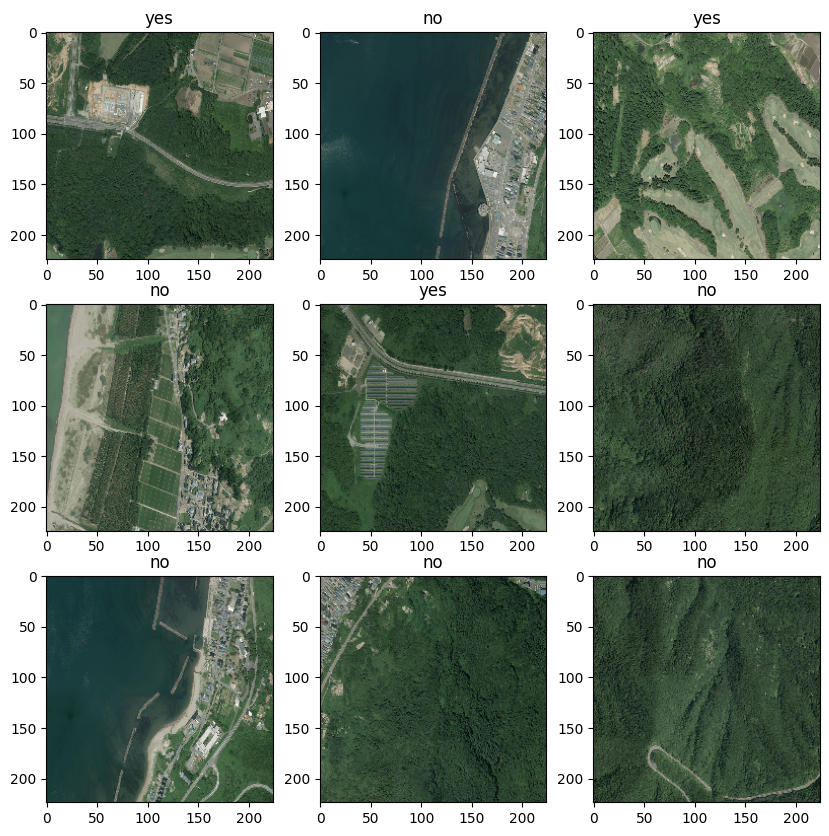

In [4]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [5]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [6]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [7]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [8]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

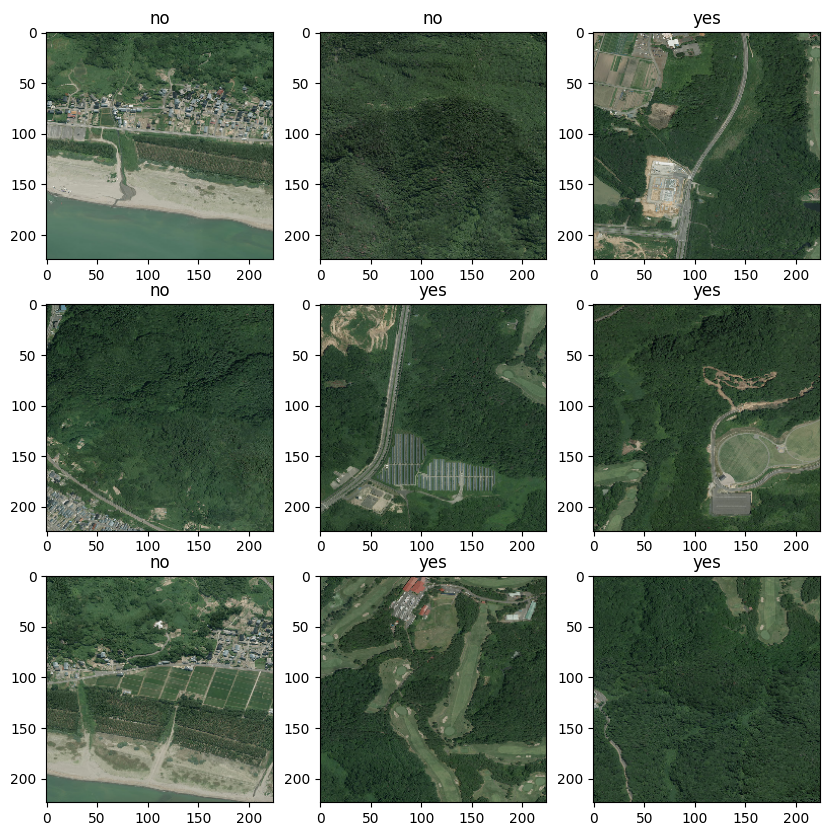

In [9]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [ ]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層の作成には tf.keras.Input() を使います。shape=(224, 224, 3) のキーワード引数には、画像のサイズと色の情報を指定
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層,正規化のための層は tf.keras.applications.mobilenet_v2.preprocess_input() で作成します。引数には入力層を指定します。これで、入力層と正規化する層が結合

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2( #MobileNetV2 のモデルは、tf.keras.applications.mobilenet_v2.MobileNetV2() で読み込み
    input_shape=(224, 224, 3), #入力層で入力される画像のサイズを指定します。今回は tf.keras.Input() で shape=(224, 224, 3) としているため、同じサイズ
    input_tensor=l_layer, #入力層を指定します。今回は、入力層と正規化する層を結合したもの（l_layer）を指定
    include_top=False, #出力層を含めるかどうかを指定します。今回は、出力層を自分で作成するため、False を指定,転移学習が可能になる
    weights="imagenet", #学習済みモデルとして利用するかの指定です。今回は、imagenet を指定
    pooling='avg' #プーリング層をどのように用意するかについて指定します。プーリング層は、畳み込み層の出力を縮小するための層,この引数では、計算手法を指定します。今回採用した avg は、平均値を計算する手法です。他には max（最大値）が指定可能
)
base_model.trainable = False #作成した MobileNetV2 のモデル全体で学習可能にするかを指定,出力層でのみ、入力された画像を学習するという指定

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


以上により、入力層 -> 正規化する層 -> 学習済みのMobileNetV2モデル という並びのモデルが作成されます。このモデルは base_model という変数に格納
続いて、出力層を作成します。出力層は、base_model に続く層として作成します。
出力層の作成には tf.keras.layers.Dense() を使う

In [ ]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')#引数の 1 は、今回の分類がゴルフ場の有無の2値分類、つまりモデルから出される答えが 1つしかない（0か1のみ出力される） ことを示すため、1 を指定
#activation には、「活性化関数」と呼ばれるものを指定します。今回は、2値分類の際に有効な sigmoid という関数名を指定すればOk

入力層（＋正規化する層）とMobileNetV2モデルの結合には、MobileNetV2() の input_tensor 引数を利用しましたが、通常は、モデルや層の結合には tf.keras.Sequential() を使います。引数には、入力層から出力層にかけての並び順をリストで指定します。

In [12]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

これで、入力層 -> 正規化する層 → 学習済みMobileNetV2モデル -> 出力層 という流れのモデルが完成し、変数 model に格納されました。最後に、このモデルの compile() を実行すれば、モデルの作成は完了です。

In [14]:
# modelをcompileする
model.compile(optimizer="adam", #optimizer：最適化手法と呼ばれる、モデルがどのように計算するかの手法を指定,今回は、adam という最適化手法を指定
              loss='binary_crossentropy', #loss：損失関数と呼ばれる、モデルの出力と正解の差を計算する関数を指定,2値分類の際に有効な binary_crossentropy という関数名を指定
              metrics=["accuracy"]) #metrics：評価関数と呼ばれる、どのようにモデルを評価するかをリスト形式で指定,今回は、正解率（accuracy）のみを指定

In [15]:
# 完成したモデルが持つ fit() を実行し、train_dataset の内容をmodelに学習させる,引数はデータセットを指定します。epochs はデータセットの学習回数(多すぎると過学習になる)
model.fit(train_dataset, epochs=20)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.7750 - loss: 0.4965
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.8917 - loss: 0.3403
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9417 - loss: 0.2425
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.9667 - loss: 0.1793
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9917 - loss: 0.1391
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.9917 - loss: 0.1104
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9917 - loss: 0.0923
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 1.0000 - loss: 0.0777
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 1.0000 - loss: 0.0666
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 1.0000 - loss: 0.0584
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 1.0000 - loss: 0.0523
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 1.0000 - lo

回数が増えるごとに accuracy、つまり訓練データ内の画像における正解率が増加しており、最終的には10割の正解率となりました。

このモデルを使って、性能を評価しましょう。テストデータを、このモデルにテスト用の画像データを入れて、分類した結果を取得します。テスト用の画像データは、すでに test_dataset に入っているので、以下のように指定

In [16]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [17]:
# 分類した結果を確認する
pred_data

array([[0.06079958],
       [0.46718636],
       [0.08130451],
       [0.98329115],
       [0.366596  ],
       [0.86286974]], dtype=float32)

分類結果は確率のような値で出力されます。0に近いほどゴルフ場は写っていない可能性が高く、逆に、1に近いほどゴルフ場は写っている可能性が高い、ということになります。
この分類結果のままだと性能が把握しづらいため、平均二乗誤差のような性能を測れる計算をしてみます。今回は model が持つ evaluate() を実行して、性能を評価します。引数には、テストデータを指定

In [ ]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)